In [ ]:
import marimo as mo
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os

In [ ]:
data=pd.read_csv('data\processed\clean_data.csv', delimiter=',')
data = data.dropna(subset=['text'])
X=data.drop(columns=['y'])
y=data['y']
X['text_len'] = X['text'].str.len()
X['word_count'] = X['text'].str.split().str.len()
X['unique_word_ratio'] = (
    X['text'].str.split().apply(lambda x: len(set(x)) / (len(x) + 1))
)
X.head()

,text,day,time,text_len,word_count,unique_word_ratio
0,awww thats a bummer you shoulda got david carr of third day to do it d,Mon,evening,70,16,0.941176
1,is upset that he cant update his facebook by texting it and might cry as a result school today also blah,Mon,evening,104,21,0.954545
2,i dived many times for the ball managed to save 50 the rest go out of bounds,Mon,evening,76,17,0.888889
3,my whole body feels itchy and like its on fire,Mon,evening,46,10,0.909091
4,no its not behaving at all im mad why am i here because i cant see you all over there,Mon,evening,85,20,0.857143


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=17,
    stratify=y
)

X_train['text'] = X_train['text'].str[:150]
X_test['text'] = X_test['text'].str[:150]


train_pool=Pool(
    X_train,
    y_train,
    cat_features=['day','time'],
    text_features=['text']
)
test_pool=Pool(
    X_test,
    y_test,
    cat_features=['day','time'],
    text_features=['text']
)

model = CatBoostClassifier(
    iterations=7000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=10,

    loss_function='Logloss',
    eval_metric='F1',

    task_type="GPU",
    devices="0",

    auto_class_weights='Balanced',

    early_stopping_rounds=200,
    bagging_temperature=1,
    random_strength=2,
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

0:	learn: 0.7786560	test: 0.7864204	best: 0.7864204 (0)	total: 307ms	remaining: 35m 50s
100:	learn: 0.7938985	test: 0.7966116	best: 0.7966116 (100)	total: 11.3s	remaining: 12m 53s
200:	learn: 0.7982913	test: 0.8012706	best: 0.8013306 (197)	total: 21.3s	remaining: 12m 1s
300:	learn: 0.8006885	test: 0.8036089	best: 0.8036089 (300)	total: 30.6s	remaining: 11m 22s
400:	learn: 0.8023936	test: 0.8051811	best: 0.8051811 (400)	total: 39.8s	remaining: 10m 54s
500:	learn: 0.8040578	test: 0.8067681	best: 0.8067681 (500)	total: 49.2s	remaining: 10m 38s
600:	learn: 0.8055611	test: 0.8080252	best: 0.8080724 (593)	total: 58.7s	remaining: 10m 25s
700:	learn: 0.8067384	test: 0.8089711	best: 0.8089711 (700)	total: 1m 8s	remaining: 10m 13s
800:	learn: 0.8078819	test: 0.8098478	best: 0.8098616 (797)	total: 1m 17s	remaining: 9m 59s
900:	learn: 0.8089272	test: 0.8105085	best: 0.8105085 (900)	total: 1m 26s	remaining: 9m 48s
1000:	learn: 0.8098883	test: 0.8112419	best: 0.8112419 (1000)	total: 1m 36s	remaining

<catboost.core.CatBoostClassifier object at 0x000001D5486432E0>

In [ ]:
y_train_prediction_cb=model.predict(X_train)
y_train_prediction_prob_cb=model.predict_proba(X_train)[:,1]
y_test_prediction_cb=model.predict(X_test)
y_test_prediction_prob_cb=model.predict_proba(X_test)[:,1]
df=pd.DataFrame(
    {"Какая выборка?": ["Train","Test"],
     "Accuracy метрика": [accuracy_score(y_train, y_train_prediction_cb),accuracy_score(y_test,y_test_prediction_cb)],
     "F1-мера": [f1_score(y_train, y_train_prediction_cb),f1_score(y_test,y_test_prediction_cb)]
        }
)
print(df)

  Какая выборка?  Accuracy метрика   F1-мера
0          Train          0.843886  0.843434
1           Test          0.823790  0.823281


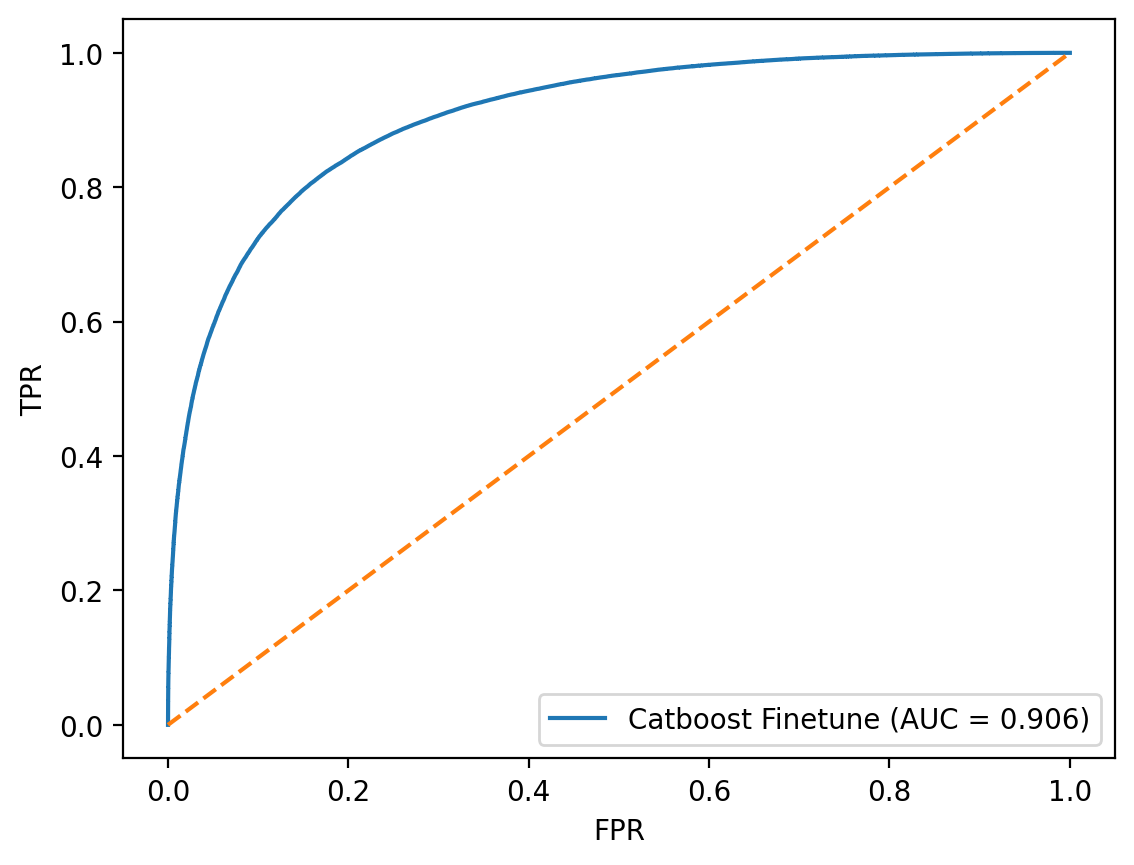

In [ ]:
#ROC-AUC
fpr_cb, tpr_cb, _ = roc_curve(y_test, y_test_prediction_prob_cb) #false positive rate (доля ложноположительных срабатываний), true positive rate (чувствительность recall)
roc_auc_cb = auc(fpr_cb, tpr_cb) #AUC = 1 — идеальная классификация, 0.5 — случайная

plt.plot(fpr_cb, tpr_cb, label=f'Catboost Finetune (AUC = {roc_auc_cb:.3f})')

plt.plot([0,1],[0,1],'--') ## Эта линия соответствует случайной модели (AUC=0.5)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.savefig('image/tune_catboost_roc_curve.png')
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_test_prediction_cb) #матрица неточностей, показывающая TP, FN, TN, FP
cm_df = pd.DataFrame(
    cm,
    index=['Negative', 'Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)

print(cm_df)
print(f"Precission for train: {precision_score(y_train, y_train_prediction_cb):.3f}\nRecall for train: {recall_score(y_train, y_train_prediction_cb):.3f}\nPrecission for test: {precision_score(y_test, y_test_prediction_cb):.3f}\nRecall for test: {recall_score(y_test, y_test_prediction_cb):.3f}")

          Predicted Negative  Predicted Positive
Negative              131973               27696
Positive               28566              131054
Precission for train: 0.846
Recall for train: 0.841
Precission for test: 0.826
Recall for test: 0.821


In [ ]:
#catboost напрямую не дает посмотреть важность слов, но дает оценить важность стобцов
fi = model.get_feature_importance(prettified=True)
print(fi.head(10))

          Feature Id  Importances
0               text    77.204410
1                day     6.532986
2           text_len     6.420526
3         word_count     5.765564
4               time     2.854600
5  unique_word_ratio     1.221913


#Итог
Провели настройку гиперпараметров модели и получили прост в 2% качества модели

##Результаты
|Метрика|Train|Test|
|:-----:|:----:|:--:|
|Accuracy|0.843899|0.823605|
|F1-мера|0.843448|0.823060|
|Recall|0.841|0.821|
|Precission|0.846|0.825|

##Матрица неточностей
||Прогноз y>0|Прогноз y<0|
|:-----:|:----:|:--:|
|Реал y>0|130992|28628|
|Реал y<0|27693|131976|

, где TP = 130992, TN = 131976, FP = 27693, FN = 28628

##Следующий шаг - повысить качество модели используя ансамбль

In [ ]:
os.makedirs('models', exist_ok=True)
package = {
    # Модели
    'model': model,    
    # Признаки
    'cat_features': ['day', 'time'],
    'text_features': ['text'],
    'text_truncate': 150,

    # Дополнительные признаки, которые добавлялись
    'engineered_features': ['text_len', 'word_count', 'unique_word_ratio']
}

# Сохраняем одним файлом
with open('models/catboost.pkl', 'wb') as f:
    pickle.dump(package, f)